This notebook shows how to use Google's [Cloud Score+](https://medium.com/google-earth/all-clear-with-cloud-score-bd6ee2e2235e) mask for Sentinel-2 images. We use [XEE](https://xee.readthedocs.io/en/latest/) extension to fetch the mask from Google Earth Engine's [Cloud Score + Collection](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_CLOUD_SCORE_PLUS_V1_S2_HARMONIZED) and apply it on a Sentinel-2 scene using Xarray. The notebook also shows how to scale this workflow for a large number of scenes and obtain a time-series of cloud-masked NDVI.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
        jupyter-server-proxy odc-algo botocore xee

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import ee
from xee import helpers
import pandas as pd
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
from matplotlib.colors import ListedColormap
from odc.stac import configure_s3_access, load


Initialize EE with the [High-Volume EndPoint](https://developers.google.com/earth-engine/guides/processing_environments#high-volume_endpoint) which is recommended to be used with XEE for workflows that do not use a lot of server side processing and are primarily for extracting data from stored collections. Replace the value of the `cloud_project` variable with your own project id that is linked with GEE.



In [ ]:
cloud_project = 'spatialthoughts' # replace with your project id

try:
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')
except:
    ee.Authenticate()
    ee.Initialize(
        project=cloud_project,
        opt_url='https://earthengine-highvolume.googleapis.com')

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

Each of our Dask workers need Earth Engine authentication. Initialize Dask workers using `ee.Initialize()`.

In [ ]:
from dask.distributed import WorkerPlugin

class EEPlugin(WorkerPlugin):
    def __init__(self):
        pass
    def setup(self, worker):
        self.worker = worker
        try:
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')
        except:
            ee.Authenticate()
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')

ee_plugin = EEPlugin()
client.register_plugin(ee_plugin)

### Masking a Single Scene

If a scene fits into memory, this approach is the most straightforward one. Let's learn this approach first and then we will see how we can scale this to a time-series.


We define a location and time of interest to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608
year = 2023

Get a single cloudy scene.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

configure_s3_access(
    aws_unsigned=True,
)
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 50},
        's2:nodata_pixel_percentage': {'lt': 10}},
    sortby=[
        {'field': 'properties.eo:cloud_cover',
         'direction': 'desc'}
        ]
)
items = search.item_collection()

# Items were sorted in descending order of cloud cover,
# so the first item is the most cloudy
most_cloudy = items[0]

ds = load(
    [most_cloudy],
    bands=['red', 'green', 'blue', 'nir', 'scl'],
    resolution=20, # Load the data at lower resolution to speed up processing
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)

scene = ds.squeeze()
# Mask nodata values
scene = scene.where(scene != 0)

# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in scene.data_vars if band != 'scl']
for band in data_bands:
  scene[band] = scene[band] * scale + offset
scene

Let’s call `compute()` to kick-off the dask graph. Dask will query the cloud-hosted dataset to fetch the required pixels. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [ ]:
%%time
scene = scene.compute()

#### Apply Cloud Score+ Mask

Cloud Score+ masks are produced by Google for every Sentinel-2 scene and are available as a ready-to-use dataset [Cloud Score+ S2_HARMONIZED V1](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_CLOUD_SCORE_PLUS_V1_S2_HARMONIZED). We find the equivalent Earth Engine id for our scene and find the matching cloud score+ mask scene.


In [ ]:
gee_product_id = most_cloudy.properties['s2:product_uri'].removesuffix('.SAFE')

gee_s2_scene = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filter(ee.Filter.eq('PRODUCT_ID', gee_product_id)) \
    .first()
gee_s2_id = gee_s2_scene.get('system:index').getInfo()
cs_plus_scene = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED') \
    .filter(ee.Filter.eq('system:index', gee_s2_id))

We now read the filtered collecting using XEE. XEE requires explicit grid parameters. We extract these from scene metadata.

In [ ]:
grid_params = dict(
    crs=str(scene.rio.crs),
    crs_transform=tuple(scene.rio.transform())[:6],
    shape_2d=(scene.rio.width, scene.rio.height),
)

ds = xr.open_dataset(
    cs_plus_scene,
    engine='ee',
    **grid_params
)
ds

Cloud Score+ comes with a `cs` band where each pixel is graded on continuous scale between 0 and 1.

* `0` = **not clear** (occluded)
* `1` = **clear** (unoccluded)

Select the `cs` band and fetch the pixels.

In [ ]:
%%time
cs_band = ds['cs'].squeeze()
cs_band = cs_band.compute()

Apply the threshold to create a cloud mask. Values between 0.50 and 0.65 generally work well. Lower values will keep more cloudy pixels in the image and higher values will remove thin clouds, haze & cirrus shadows.

In [ ]:
CLEAR_THRESHOLD = 0.5
cs_mask = cs_band < CLEAR_THRESHOLD

Apply the mask on our scene.

In [ ]:
scene_masked_csplus = scene[data_bands].where(~cs_mask)
scene_masked_csplus

#### Visualize the Results

Let's visualize and compare both the masks.


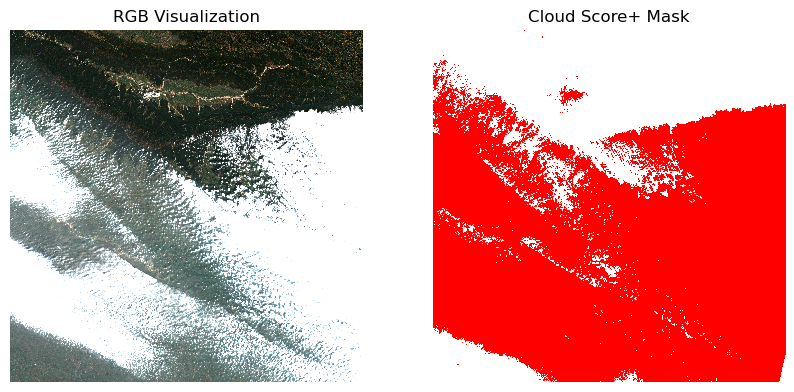

In [ ]:
scene_preview = scene[['red', 'green', 'blue']].to_array('band')\
  .rio.reproject(
    scene.rio.crs, resolution=100
)

cs_mask_preview = cs_mask.astype('uint8').rio.reproject(
    cs_mask.rio.crs, resolution=100
)

fig, (ax0, ax1) = plt.subplots(1, 2)
fig.set_size_inches(10,5)
scene_preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax0,
    vmin=0, vmax=0.3)
ax0.set_title('RGB Visualization')

# RGBA: Transparent, Red
mask_colormap = ListedColormap(['#00000000', '#FF0000FF'])
cs_mask_preview.plot.imshow(
    ax=ax1,
    cmap=mask_colormap,
    add_colorbar=False)

ax1.set_title('Cloud Score+ Mask')


for ax in (ax0, ax1):
  ax.set_axis_off()
  ax.set_aspect('equal')
plt.show()

#### Save the Masked Scene

In [ ]:
cs_mask_file = f'scene_cs_masked.tif'
cs_mask_path = os.path.join(output_folder, cs_mask_file)
scene_masked_csplus.to_array(dim='band').rio.to_raster(cs_mask_path, driver='COG')

### Masking a Time-Series

If you'd like to apply the Cloud Score+ mask, it is most efficient to do the masking in GEE itself and open the resuling masked dataset using XEE. We use the Google Earth Engine Python API to load the Sentinel-2 Level-2A collection, apply filters to select the scenes, and apply the Cloud Score+ mask.

In [ ]:
geometry = ee.Geometry.Point([longitude, latitude])

In [ ]:
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')

startDate = ee.Date.fromYMD(year, 1, 1)
endDate = ee.Date.fromYMD(year+1, 1, 1)

filtered = s2 \
  .filter(ee.Filter.date(startDate, endDate)) \
  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
  .filter(ee.Filter.lt('NODATA_PIXEL_PERCENTAGE', 10)) \
  .filter(ee.Filter.bounds(geometry))

# Load the Cloud Score+ collection
csPlus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
csPlusBands = csPlus.first().bandNames()

# We need to add Cloud Score + bands to each Sentinel-2
# image in the collection
# This is done using the linkCollection() function
filteredS2WithCs = filtered.linkCollection(csPlus, csPlusBands)

# Function to mask pixels with low CS+ QA scores.
def maskLowQA(image):
  qaBand = 'cs'
  clearThreshold = 0.5
  mask = image.select(qaBand).gte(clearThreshold)
  return image.updateMask(mask)

filteredMasked = filteredS2WithCs \
  .map(maskLowQA)

# Write a function that computes NDVI for an image and adds it as a band
def addNDVI(image):
  ndvi = image.normalizedDifference(['B8', 'B4']).rename('ndvi')
  return image.addBands(ndvi)

# Map the function over the collection
ndviCol = filteredMasked.map(addNDVI).select(['ndvi'])

In [ ]:
grid_params = helpers.extract_grid_params(ndviCol)
grid_params

In [ ]:
ds_masked_csplus = xr.open_dataset(
    ndviCol,
    engine='ee',
    **grid_params,
    chunks={}
)
ds_masked_csplus

### Extract a Cloud-Masked NDVI Time Series

Following the course's [time-series workflow](#extracting-and-processing-time-series), we extract an NDVI time series at a point of interest from the masked stack.

Our location coordinates are in EPSG:4326 Lat/Lon. Convert it to the CRS of the dataset so we can query it.

In [ ]:
crs = ds_masked_csplus.rio.crs
transformer = pyproj.Transformer.from_crs('EPSG:4326', crs, always_xy=True)
x, y = transformer.transform(longitude, latitude)
x,y

Query NDVI values at the coordinates.

In [ ]:
time_series = ds_masked_csplus.ndvi \
  .interp(y=y, x=x, method='nearest')
time_series

In [ ]:
# As we are proceesing the time-series,
# it needs to be in a single chunk along the time dimension
time_series = time_series.chunk(dict(time=-1))
time_series

Run the calculation and load the results into memory.

In [ ]:
%%time
time_series = time_series.compute()

Plot the time-series. The missing values are pixels where the OmniCloudMask predicted a cloud.

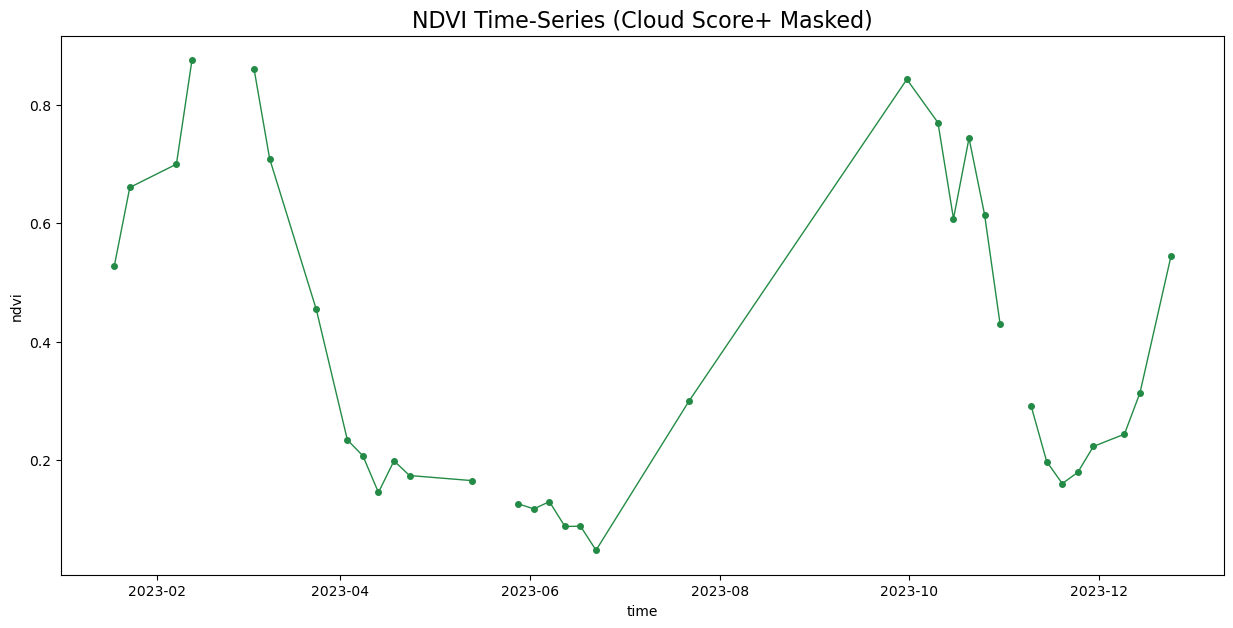

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 7)

time_series.plot.line(
    ax=ax, x='time',
    marker='o', color='#238b45',
    linestyle='-', linewidth=1, markersize=4)

# Format the x-axis to display dates as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

ax.set_title('NDVI Time-Series (Cloud Score+ Masked)', fontsize=16)
plt.show()

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()